# Finding the Best Neighborhood
## Introduction
In our opinion, the best neighborhood is the one that provides residents with the best quality of life. We used three metrics to measure this: Number of parks, size of neighborhood, and crime rate. We explored other avenues to describe the best neighborhood such as best homes. However, finding what neighborhood has the best homes is very opinion based and metrics such as square-feet doesn't truly measure how nice a house it. We stuck to quality of life because if we were potential homebuyers, we would settle in a neighborhood that has the best quality of life over any other metric. 

## Metric #1: Number of Parks
Number of parks was selected as a metric because it can be seen as a way to measure the quality of the town. The number of quality parks shows that there is a willingness from town leadership to create useful amenities for the town residents.

Here are the pros of selecting this as a metric:
* Access to green space and recreation
* Environmental benefits
* Community and social value
* Property value
* Willingness to invest in amenities

Here are the cons:
* The number of parks doesn’t indicate quality
* Ignores park size
* Overlooks park usage
* Biases rankings towards low density neighborhoods

### Dataset 1: City Parks
The City Parks dataset has not been updated since 2021 meaning our data is inaccurate to the current year. The important information the dataset lists is the park’s name, type, and neighborhood. 
Here is a link to the dataset: https://data.wprdc.org/datastore/dump/fa329e3d-89ff-4708-8ddf-81bfedcad11d

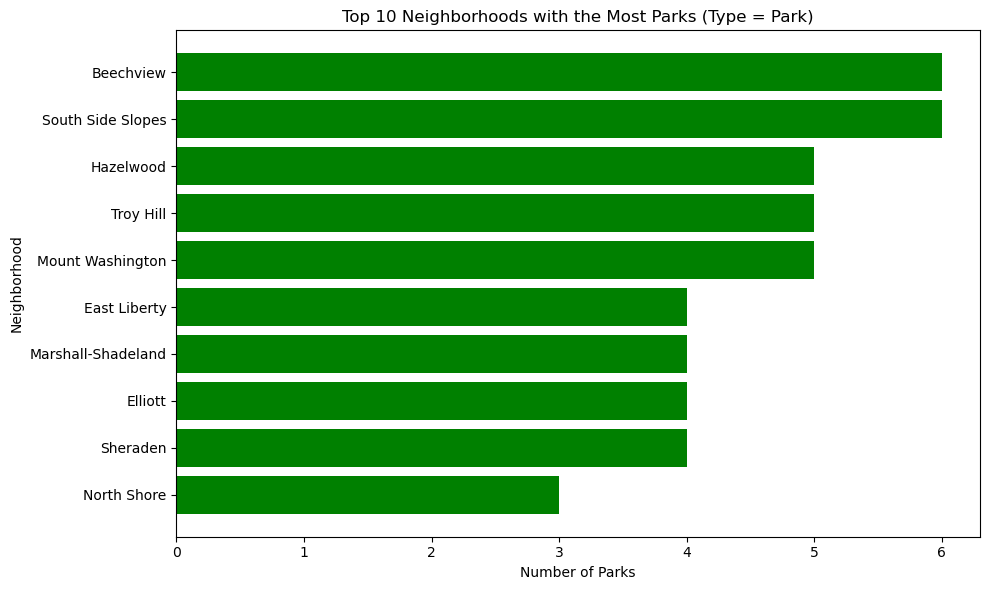

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

parks = pd.read_csv("parks.tsv", sep="\t")

#makes sure we are only counting parks in the set
parks.columns = parks.columns.str.strip()
parks = parks[parks["type"].str.strip().eq("Park")]

#counts parks in each neighborhood
parks_per_neighborhood = parks.groupby("neighborhood").size().reset_index(name="num_parks")


top10_parks = parks_per_neighborhood.sort_values(by="num_parks", ascending=False).head(10)

#bar graph
plt.figure(figsize=(10,6))
plt.barh(top10_parks["neighborhood"], top10_parks["num_parks"], color="green")
plt.xlabel("Number of Parks")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Most Parks (Type = Park)")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

## Metric #2: Size of Neighborhood
Size of neighborhood was chosen as a measure of the town's expected future growth. The size of the town dictates the room the town has to create new infrastructure, schools, residential areas, etc.

Here are the pros:
* More projected growth for the neighborhood
* More space to walk around
* Shows that there can be more space to build


Here are the cons:
* Doesn’t take into account hills
* Could include water
* Could mean things are farther away from people in the neighborhood


### Dataset 2: Neighborhoods
This dataset contains general information about each neighborhood in Pittsburgh. It lists perimeter size, acres, sq miles and more. This dataset is kept up to date.
Here is a link to the dataset: https://data.wprdc.org/dataset/neighborhoods2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


neigh = pd.read_csv("neighborhoods.tsv" , sep="\t")
neigh.columns = neigh.columns.str.strip()


#stores the acres of each neighborhood
neigh_cols = [col for col in neigh.columns if "acres" in col]
neigh["largest_neighborhood"] = neigh[neigh_cols]



#sorts them from largest to smallest
top10_biggest = neigh.sort_values(by="largest_neighborhood", ascending=False).head(10)



#bar graph
plt.figure(figsize=(10,6))
plt.barh(top10_biggest["hood"], top10_biggest["largest_neighborhood"], color="red")
plt.xlabel("Acres")
plt.ylabel("Neighborhood")
plt.title("Top 10 Largest Neighborhoods")

#shows largest at top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Metric #3: Crime Rate
Crime rate was chosen as a measure of the town's safety. When the town is safer people are more likely to participate in residential events. Because of this more people will contribute to the community.

Here are the pros:
* Quality of life
* Normalizes to population (per capita)
* Influences property value
* Widely collected data



Here are the cons:
* Crime can be underreported in some areas
* Affected by population size and density
* Crime hotspots can inflate the whole neighborhood crime rate
* Can reinforce biases



### Dataset 3: Neighborhood Atlas
This dataset uses crime rate statistics from 1973-1975 in each Pittsburgh Neighborhood. This data will likely be a bit more outdated.
Here is a link to the dataset: https://data.wprdc.org/dataset/pittsburgh-neighborhood-atlas-1977

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


crime = pd.read_csv("crime_rate.tsv" , sep="\t")
crime.columns = crime.columns.str.strip()


#takes the mean of crime rate across every year
crime_rate_cols = [col for col in crime.columns if "neighborhood_crime_rate" in col]
crime["total_crime_rate"] = crime[crime_rate_cols].mean(axis=1)



#sorts by lowest crime rate
top10_lowest = crime.sort_values(by="total_crime_rate", ascending=True).head(10)



#bar graph
plt.figure(figsize=(10,6))
plt.barh(top10_lowest["neighborhood"], top10_lowest["total_crime_rate"], color="skyblue")
plt.xlabel("Total Crime Rate")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Lowest Crime Rate")

#shows lowest to largest
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## Conclusion
We decided to make an algorithm to find the exact best neighborhood that fit our "quality of life" title.

In [ ]:
largest = neigh. sort_values(by="largest_neighborhood", ascending=False)
lowest_cr = crime.sort_values(by="total_crime_rate", ascending=True)
most_parks = parks_per_neighborhood.sort_values(by="num_parks", ascending=False)

largest = largest.rename(columns={'hood': 'neighborhood'})

#this creates a new col that just numbers the ranks determined in earlier code
largest = largest.reset_index(drop=True).reset_index().rename(columns={'index': 'rank_largest'})
lowest_cr = lowest_cr.reset_index(drop=True).reset_index().rename(columns={'index': 'rank_lowest_cr'})
most_parks = most_parks.reset_index(drop=True). reset_index().rename(colunns={'index': 'rank_most_parks'})

merged = {
largest
.merge(lowest_cr, on="neighborhood", how="inner")
.merge(most_parks, on="neighborhood", how="inner")
}

#get combined rankings far each neighborhood
merged["combined_rank"] = {
merged["rank_largest"] + merged["rank_lowest_cr"] + merged["rank_most_parks"]
}

#finds best neighborhood
best_overall = merged. loc[merged["combined_rank"].idxmin()]

print(best_overall[["neighborhood", "rank_largest", "rank_lowest_cr", "rank_most_parks", "combined_rank"]])


Beechview was chosen. It ranks 7th in its size, 14th in crime rate and 1st in most parks. Unfortunately this is not going to be as accurate of a reading becuase two of our data sets are quite outdated.

Evan: Personally, I expected the best neighborhood to show up as Shadyside becuase its crime rate is low and there is a lot of great restaurants around.

Rohan: I thought Squirrel hill was going to be the best, I go there a lot with my friends because there is so much to do. I also think that a lot of people would agree that Squirrel hill is one of the best areas to visit here in pittsburgh.